# Notebook 01 — Marker Reconstruction & Trajectories

> **Supplementary §2–§3**

This notebook loads the flight trajectory data and explores the whole-body kinematics of hawk landing flights. The hawks are treated as single points (backpack position) with a body vector (backpack → tail-clip). We examine flight trajectories, speed profiles, accelerations, and body pitch across experimental conditions.

## Contents
1. [Setup](#setup)
2. [Loading and filtering trajectory data](#loading-and-filtering-data)
3. [Side-view trajectories (XZ)](#side-view-trajectories-xz)
4. [Top-view trajectories (XY)](#top-view-trajectories-xy)
5. [Total speed](#total-speed)
6. [Forward acceleration (Y)](#forward-acceleration-y)
7. [Upward acceleration (Z)](#upward-acceleration-z)
8. [Body pitch](#body-pitch)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'

from kinematic_morphospace import (
    load_data, remove_frames, add_turn_info,
    bin_by_horz_distance,
)
from kinematic_morphospace.plotting import (
    plot_traj, plot_traj_scatter, save_figure,
)

## Loading and Filtering Data

We load the hawk flight trajectory data from CSV and apply several filtering steps:

1. Load the trajectory dataset containing position, velocity, and acceleration data.
2. Remove frames where horizontal distance to perch > 0.1 m (post-landing) or time < −0.5 s (pre-takeoff).
3. Bin by horizontal distance for analysis.
4. Add obstacle flight turn direction (left/right).
5. Remove sequences where the hawk started too low or ended too far from the perch.

These steps ensure we analyse only frames where hawks are in flight and successfully approaching the perch.

In [2]:
# Load trajectory dataframe
traj_df = load_data("../../data/raw/trajectories.csv")

# Remove non-flying frames
traj_df = remove_frames(traj_df, Y_limit=0.1, time_limit=-0.5)

# Bin horizontal distance
traj_df, bin_labels = bin_by_horz_distance(traj_df)

# Add turn direction for obstacle flights
turn_csv_path = "../../data/raw/obstacle_turns.csv"
traj_df = add_turn_info(traj_df, turn_csv_path)

# Remove NaN bins and convert to float
traj_df = traj_df[~traj_df['bins'].isna()]
traj_df['bins'] = traj_df['bins'].astype(float)

# Remove flights where the hawk did not take off properly
n_flights = traj_df['seqID'].nunique()
traj_df = traj_df[
    traj_df.groupby('seqID')['smooth_XYZ_3'].transform(
        lambda x: x.head(10).median() > 0
    )
]
print(f"Flights removed (did not take off): {n_flights - traj_df['seqID'].nunique()}")
print(f"Remaining: {len(traj_df):,} frames")

Starting with 939383 frames.
Removed frames with time less than -0.5. This removes frames before takeoff jump.
-- Number of frames removed: 93298
Detected mostly positive HorzDistance values. Flipping the sign.
Removed frames with Y greater than 0.1.
-- Number of frames removed: 18053
Now 814096 frames.
Added turn direction to dataframe.
Flights removed (did not take off): 1
Remaining: 813,374 frames


## Side-View Trajectories (XZ)

The following plots show hawk trajectories in the vertical plane (side view, left to right). For each experimental condition, the left panel shows all individual flight traces and the right panel shows binned means per individual bird.

Conditions: 5 m, 7 m, 9 m, 12 m (Period 1), and 9 m control, obstacle, weight, obstacle + weight (Period 2).

Note that Drogon flies lowest relative to the floor, while Ruby (the only female, and the largest hawk) flies highest.

Plotting 5m, 2017, obstacle=0, weight=0
n = 91364 points, n_flights = 335
Plotting 7m, 2017, obstacle=0, weight=0
n = 95040 points, n_flights = 278
Plotting 9m, 2017, obstacle=0, weight=0
n = 118606 points, n_flights = 326
Plotting 12m, 2017, obstacle=0, weight=0
n = 206909 points, n_flights = 659
Plotting 9m, 2020, obstacle=0, weight=0
n = 116251 points, n_flights = 188
Plotting 9m, 2020, obstacle=1, weight=0
n = 72600 points, n_flights = 128
Plotting 9m, 2020, obstacle=0, weight=1
n = 38593 points, n_flights = 67
Plotting 9m, 2020, obstacle=1, weight=1
n = 74011 points, n_flights = 127
Saved: ../../figures/supplementary/S02_XZ_trajectories.pdf


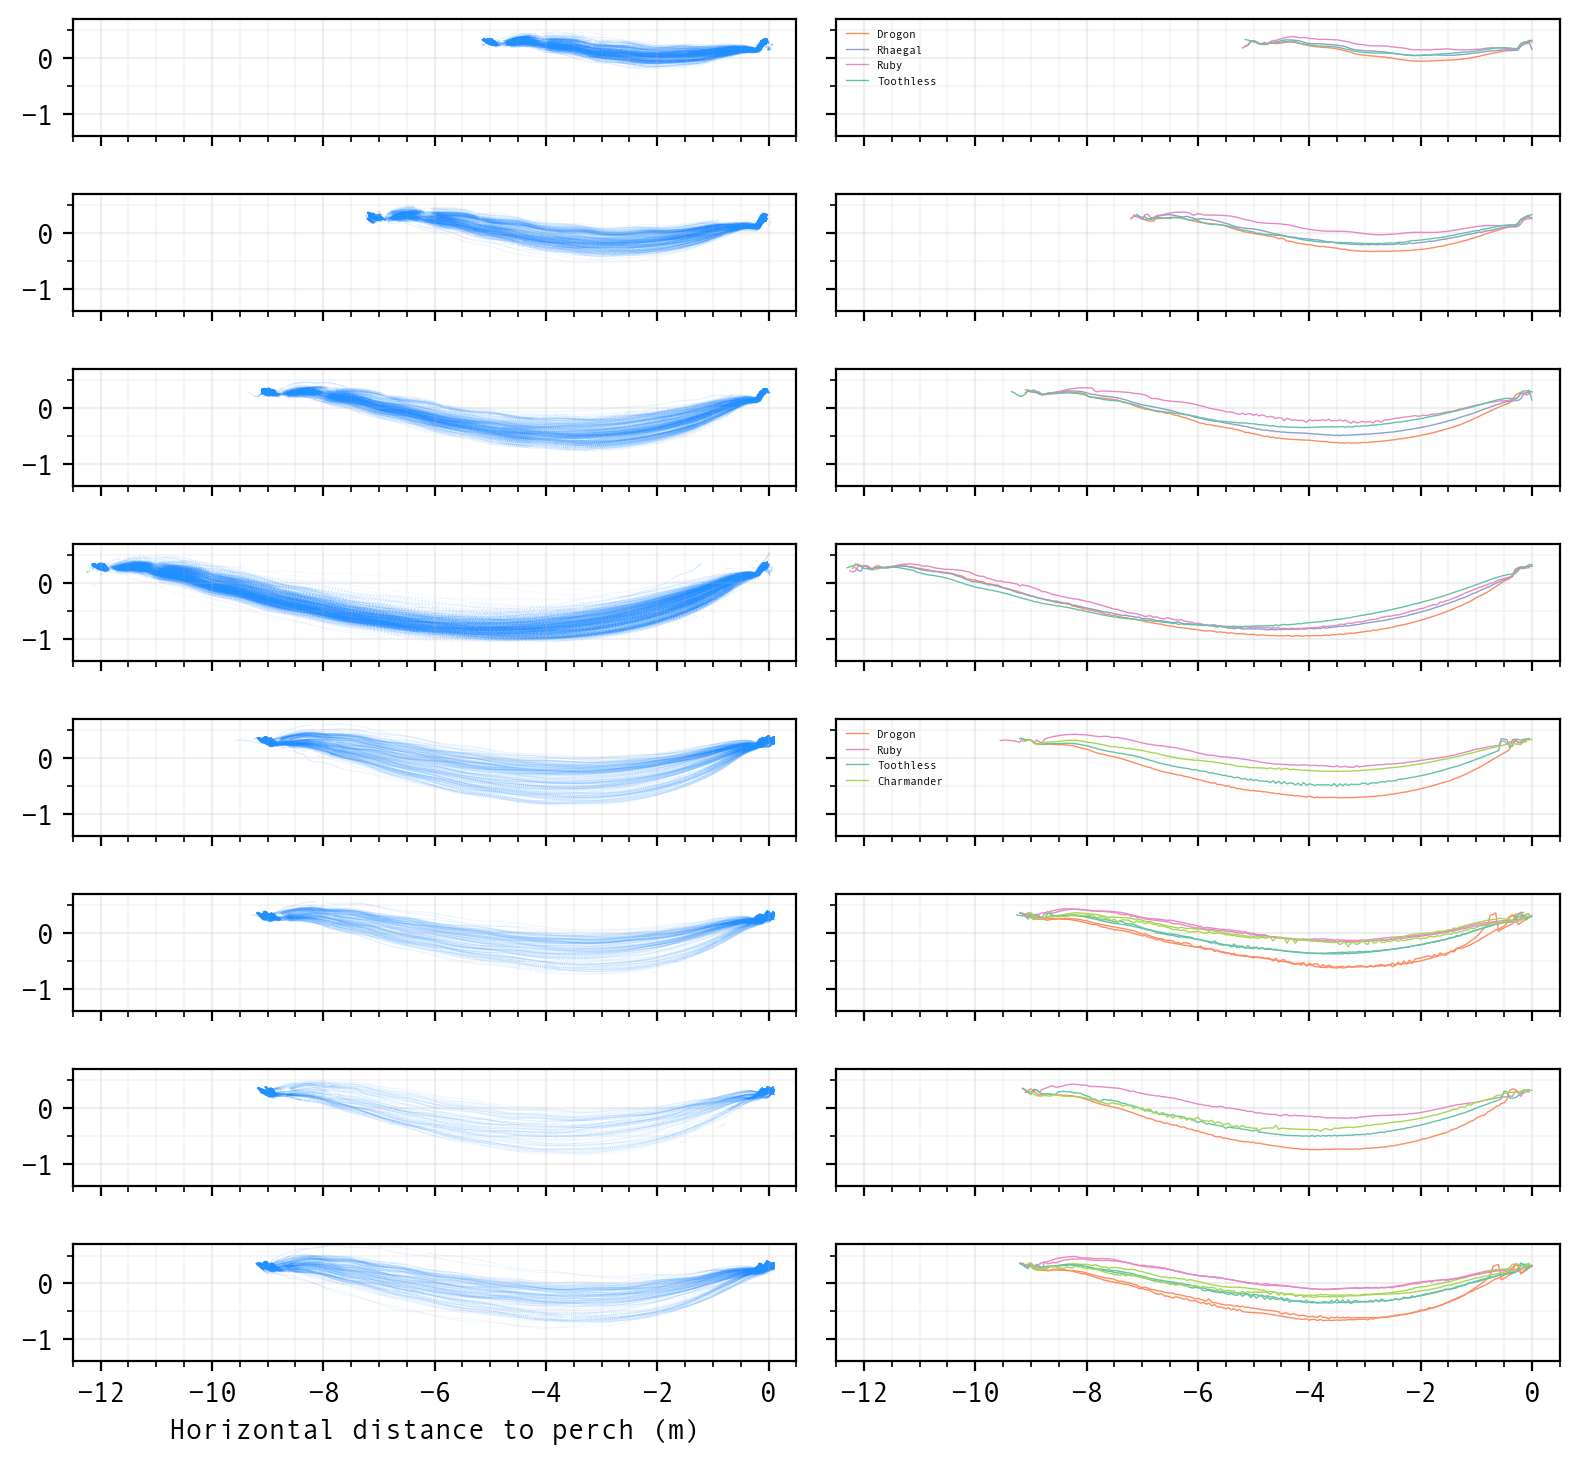

In [3]:
fig, axes = plot_traj(traj_df, 'smooth_XYZ_2', 'smooth_XYZ_3', print_n_flights=True)

save_figure(fig, '../../figures/supplementary/S02_XZ_trajectories.pdf', rasterize=True)

## Top-View Trajectories (XY)

Trajectories in the horizontal plane (top-down view). In obstacle conditions the flights curve left or right around the pole. Even without obstacles, flight paths are not strictly straight.

Plotting 5m, 2017, obstacle=0, weight=0
Plotting 7m, 2017, obstacle=0, weight=0
Plotting 9m, 2017, obstacle=0, weight=0
Plotting 12m, 2017, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=1, weight=0
Plotting 9m, 2020, obstacle=0, weight=1
Plotting 9m, 2020, obstacle=1, weight=1
Saved: ../../figures/supplementary/S02_XY_trajectories.pdf


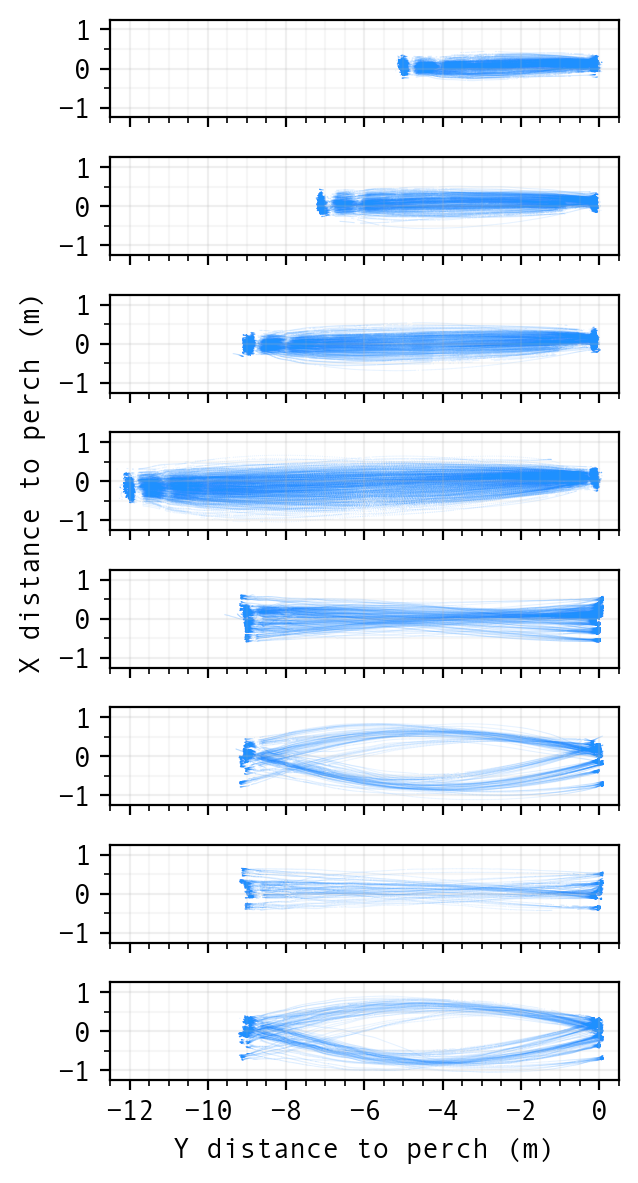

In [4]:
traj_df_copy = traj_df.copy()
fig, axes = plot_traj_scatter(traj_df_copy, 'smooth_XYZ_2', 'smooth_XYZ_1')

for ax in axes:
    ax.set_ylim([-1.25, 1.25])
    ax.set_yticks([-1, 0, 1])
axes[-1].set_xlabel('Y distance to perch (m)')
axes[3].set_ylabel('X distance to perch (m)')

save_figure(fig, '../../figures/supplementary/S02_XY_trajectories.pdf', rasterize=True)

## Total Speed

Total speed is computed from the velocity components:

$$v_{\text{total}} = \sqrt{v_X^2 + v_Y^2 + v_Z^2}$$

Drogon is the fastest bird; Ruby the slowest. Ruby uses flapping flight for longer, whereas the males transition to gliding earlier.

In [ ]:
traj_df["TotalSpeed"] = np.sqrt(
    traj_df["vel_XYZ_1"]**2 +
    traj_df["vel_XYZ_2"]**2 +
    traj_df["vel_XYZ_3"]**2
)

# Exclude bins with fewer than 10 datapoints per hawk to avoid
# unreliable medians at the start/end of flight trajectories.
fig, axes = plot_traj(traj_df, x_axis_column='smooth_XYZ_2', y_axis_column='TotalSpeed', equal=False, min_samples=10)

for ax in axes:
    ax.set_ylim([0, 10])
    ax.set_yticks([0, 5, 10])
    ax.set_yticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], minor=True)
    ax.grid(which='minor', alpha=0.1)
axes[6].set_ylabel('Total speed (m/s)')

save_figure(fig, '../../figures/supplementary/S02_total_speed.pdf', rasterize=True)

## Forward Acceleration (Y)

Forward acceleration (Y-axis) is a proxy for thrust. Due to double differentiation, it is noisier than velocity. Negative thrust is visible within each wingbeat cycle (upstroke drag may exceed thrust). The difference between flapping and gliding is also apparent.

Plotting 5m, 2017, obstacle=0, weight=0
Plotting 7m, 2017, obstacle=0, weight=0
Plotting 9m, 2017, obstacle=0, weight=0
Plotting 12m, 2017, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=1, weight=0
Plotting 9m, 2020, obstacle=0, weight=1
Plotting 9m, 2020, obstacle=1, weight=1
Saved: ../../figures/supplementary/S02_Y_acceleration.pdf


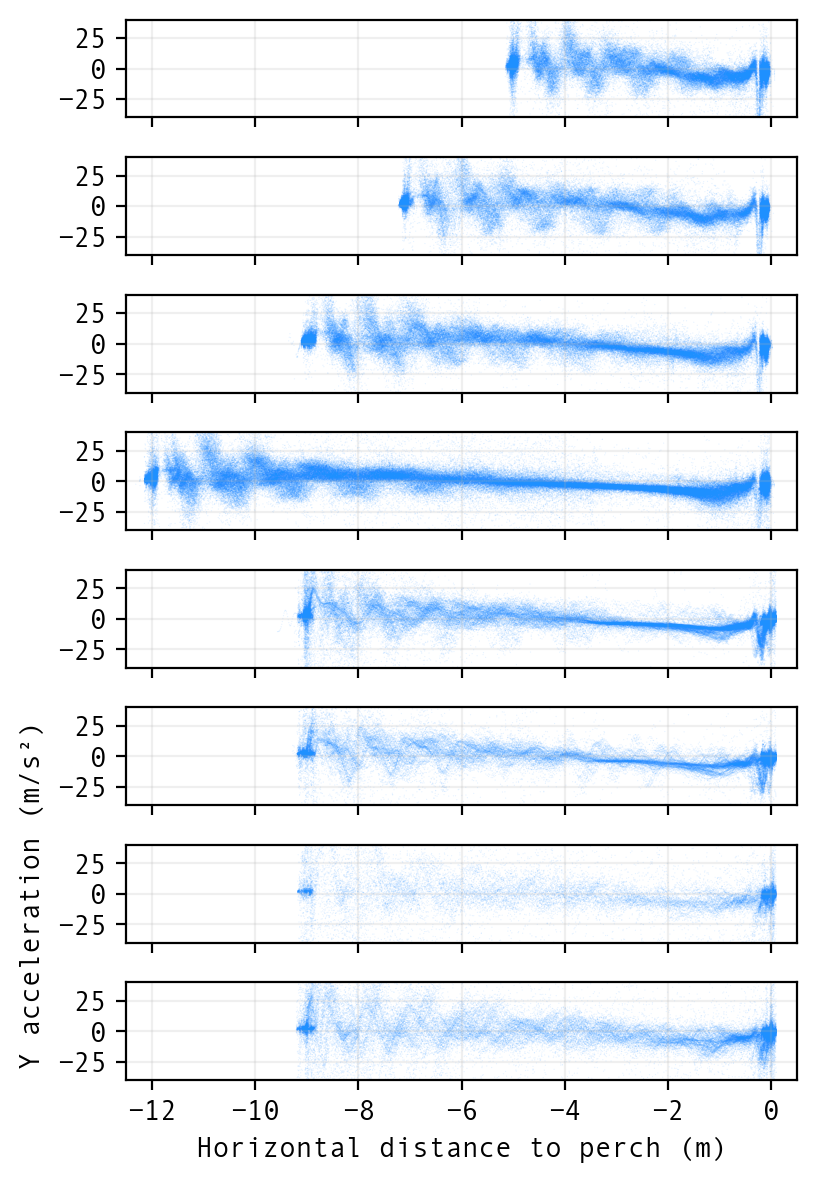

In [6]:
fig, axes = plot_traj_scatter(
    traj_df,
    x_axis_column='smooth_XYZ_2',
    y_axis_column='acc_XYZ_2',
    equal=False,
)

for ax in axes:
    ax.set_ylim([-40, 40])
axes[6].set_ylabel('Y acceleration (m/s²)')
axes[-1].set_xlabel('Horizontal distance to perch (m)')

save_figure(fig, '../../figures/supplementary/S02_Y_acceleration.pdf', rasterize=True)

## Upward Acceleration (Z)

Z-axis acceleration serves as a proxy for lift. Differences in wingbeat frequency between individuals and flights contribute noise.

Plotting 5m, 2017, obstacle=0, weight=0
Plotting 7m, 2017, obstacle=0, weight=0
Plotting 9m, 2017, obstacle=0, weight=0
Plotting 12m, 2017, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=1, weight=0
Plotting 9m, 2020, obstacle=0, weight=1
Plotting 9m, 2020, obstacle=1, weight=1
Saved: ../../figures/supplementary/S02_Z_acceleration.pdf


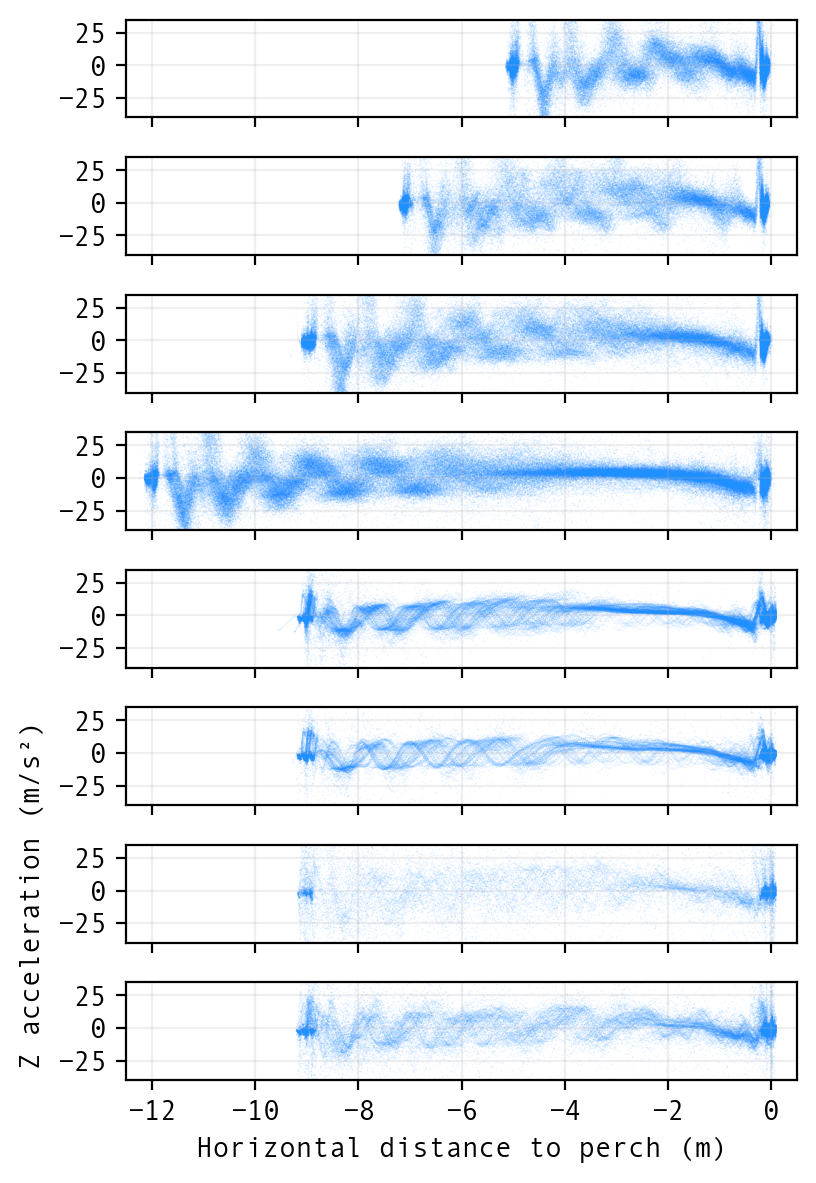

In [7]:
fig, axes = plot_traj_scatter(
    traj_df,
    x_axis_column='smooth_XYZ_2',
    y_axis_column='acc_XYZ_3',
    equal=False,
)

for ax in axes:
    ax.set_ylim([-40, 35])
axes[6].set_ylabel('Z acceleration (m/s²)')
axes[-1].set_xlabel('Horizontal distance to perch (m)')

save_figure(fig, '../../figures/supplementary/S02_Z_acceleration.pdf', rasterize=True)

## Body Pitch

Whole-body pitch is estimated from the angle between the backpack and tail-clip markers. During landing manoeuvres, body pitch changes considerably as part of the rapid pitch-up braking manoeuvre. Note that this is **not** the angle of attack — that would require an estimate of the velocity vector direction and wing angle.

Plotting 5m, 2017, obstacle=0, weight=0
Plotting 7m, 2017, obstacle=0, weight=0
Plotting 9m, 2017, obstacle=0, weight=0
Plotting 12m, 2017, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=0, weight=0
Plotting 9m, 2020, obstacle=1, weight=0
Plotting 9m, 2020, obstacle=0, weight=1
Plotting 9m, 2020, obstacle=1, weight=1
Saved: ../../figures/supplementary/S02_kinematics_pitch.pdf


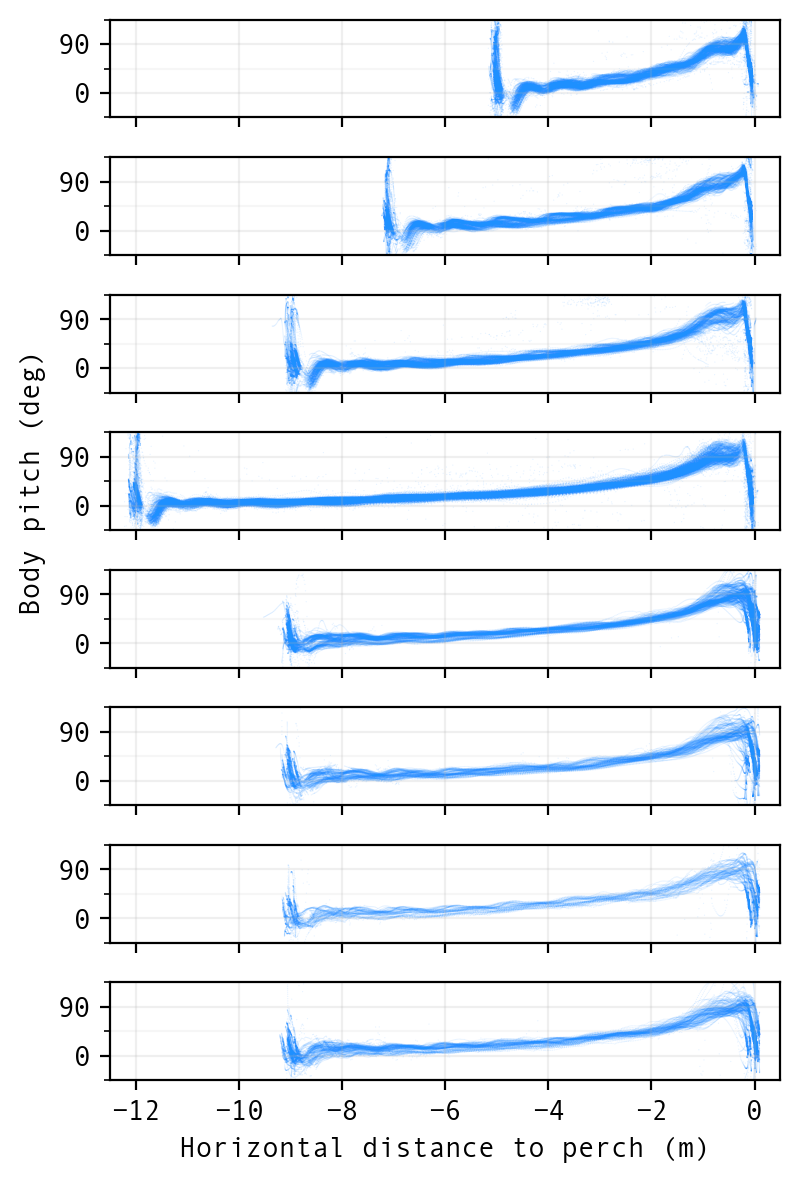

In [8]:
fig, axes = plot_traj_scatter(
    traj_df,
    x_axis_column='smooth_XYZ_2',
    y_axis_column='body_pitch',
    equal=False,
)

for ax in axes:
    ax.set_ylim([-45, 130])
    ax.set_yticks([0, 90])
    ax.set_yticks([-45, 0, 45, 90, 135], minor=True)
    ax.grid(which='minor', alpha=0.1)
axes[3].set_ylabel('Body pitch (deg)')
axes[-1].set_xlabel('Horizontal distance to perch (m)')

save_figure(fig, '../../figures/supplementary/S02_kinematics_pitch.pdf', rasterize=True)

---

## References

- KleinHeerenbrink, M., France, L. A., Brighton, C. H. & Taylor, G. K. (2022). Optimization of avian perching manoeuvres. *Nature*, 607, 91–96.
- Carruthers, A. C., Thomas, A. L. R. & Taylor, G. K. (2007). Automatic aeroelastic devices in the wings of a steppe eagle *Aquila nipalensis*. *Journal of Experimental Biology*, 210, 4136–4149.